In [24]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
from pathlib import Path
from IPython.display import display, HTML, Markdown
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ Libraries loaded.")

✅ Libraries loaded.


## Comparative Analysis

Visual comparison of the network graphs overlaid on the original images for the three datasets.

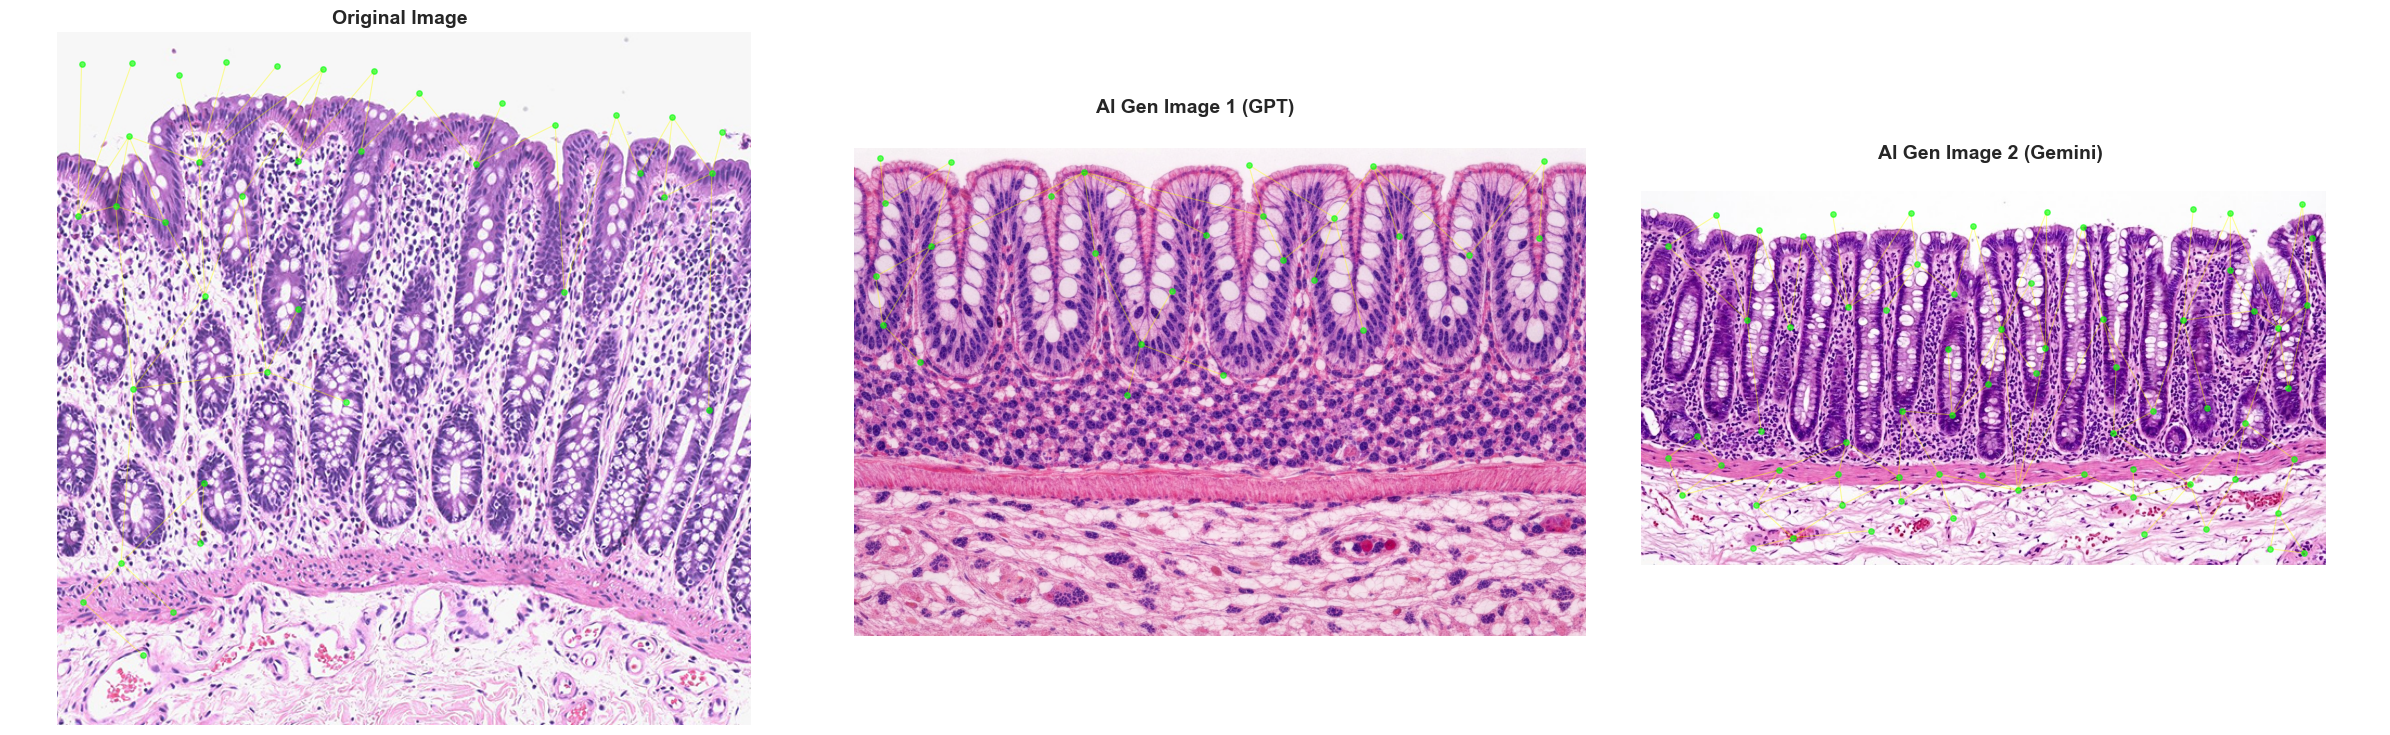

In [25]:
# Configuration for the 3 images
COMPARISON_CONFIG = [
    {
        "title": "Original Image",
        "output_dir": Path('../output_results/Original_Image/Original_Image'),
        "image_path": Path('../Original Image/Histopathology Image.jpg') 
    },
    {
        "title": "AI Gen Image 1 (GPT)",
        "output_dir": Path('../output_results/AI_Gen_1_GPT/AI_Gen_1_GPT'),
        "image_path": Path('../GPT Image Gen/653601e7-f502-43f3-bc50-c682685b7c3a.png')
    },
    {
        "title": "AI Gen Image 2 (Gemini)",
        "output_dir": Path('../output_results/AI_Gen_2_Gemini/AI_Gen_2_Gemini'),
        "image_path": Path('../Gemini Nano Banana/unnamed.jpg')
    }
]

def load_and_visualize_overlay(config, ax):
    output_dir = config['output_dir']
    image_path = config['image_path']
    title = config['title']
    
    # Load Graph
    graph_path = output_dir / 'rag.graphml'
    nodes_path = output_dir / 'nodes.csv'
    
    if not graph_path.exists() or not nodes_path.exists():
        ax.text(0.5, 0.5, f"Data not found for {title}\n{output_dir}", ha='center', va='center')
        ax.axis('off')
        return

    try:
        G = nx.read_graphml(graph_path)
        nodes_df = pd.read_csv(nodes_path)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error loading data for {title}:\n{str(e)}", ha='center', va='center')
        ax.axis('off')
        return
    
    # Load Image
    if image_path.exists():
        try:
            img = plt.imread(image_path)
            ax.imshow(img)
        except Exception as e:
             ax.text(0.5, 0.5, f"Error loading image: {str(e)}", ha='center', va='center')
    else:
        ax.text(0.5, 0.5, f"Image not found: {image_path}", ha='center', va='center')
    
    # Get positions from nodes_df
    # Assuming 'centroid_col' is x and 'centroid_row' is y
    pos = {}
    if 'centroid_col' in nodes_df.columns and 'centroid_row' in nodes_df.columns:
        for _, row in nodes_df.iterrows():
            node_id = str(row['node'])
            # Check if node is in graph (sometimes graph has fewer nodes if filtered)
            if node_id in G.nodes():
                pos[node_id] = (row['centroid_col'], row['centroid_row'])
    else:
        # Fallback if columns are different
        pos = nx.spring_layout(G)
        print(f"Warning: Centroid columns not found for {title}. Using spring layout.")

    # Draw Graph
    if pos:
        nx.draw_networkx_nodes(G, pos, node_size=15, node_color='lime', alpha=0.6, ax=ax)
        nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='yellow', width=0.8, ax=ax)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for i, config in enumerate(COMPARISON_CONFIG):
    load_and_visualize_overlay(config, axes[i])
plt.tight_layout()
plt.show()

### Understanding the Network Graph Overlay Visualization

---

#### 🔬 Visualization Overview

This visualization displays **Region Adjacency Graphs (RAGs)** overlaid on three image sources to enable comparative analysis of image structure:

- **Nodes (green dots)**: Represent superpixel regions identified through SLIC segmentation. Each node corresponds to a perceptually homogeneous region in the image.
- **Edges (yellow lines)**: Connect adjacent superpixels, representing spatial proximity and boundary relationships between regions.
- **Node positions**: Derived from superpixel centroids, preserving the spatial topology of the original image.

**Research Applications**:
- Compare structural complexity between original and AI-generated images
- Analyze how AI image generators preserve or alter spatial relationships
- Quantify differences in texture granularity and region connectivity

---

#### 💻 Technical Implementation

**Implementation Details**:

```python
# Key components:
1. Graph Loading: nx.read_graphml() loads the pre-computed RAG
2. Position Mapping: Centroid coordinates (centroid_row, centroid_col) from nodes.csv
3. Overlay: matplotlib imshow() for image + networkx draw functions for graph
```

**Data Flow**:
- `rag.graphml` → NetworkX Graph object
- `nodes.csv` → Node positions via centroid coordinates  
- `plt.imread()` → Background image array
- `nx.draw_networkx_nodes/edges()` → Graph overlay

**Customization Points**:
- `node_size=15` - Adjust for visibility
- `alpha=0.6/0.4` - Transparency for nodes/edges
- `edge_color='yellow'`, `node_color='lime'` - High contrast against images

---

#### 📚 Theoretical Context

This visualization demonstrates the application of **graph theory** to **computer vision**, specifically:

1. **Image Segmentation**: SLIC (Simple Linear Iterative Clustering) algorithm partitions images into perceptually meaningful superpixels
   
2. **Graph Construction**: The Region Adjacency Graph transforms pixel-level data into a graph structure where:
   - Vertices = image regions
   - Edges = spatial adjacency relationships

3. **Comparative Analysis**: By applying identical processing to original vs. AI-generated images, one can:
   - Observe structural differences in graph topology
   - Understand how generative models represent spatial coherence
   - Explore metrics like graph density, connectivity, and community structure

**Learning Objectives**:
- Understand the bridge between continuous image data and discrete graph representations
- Apply network analysis techniques to visual data
- Critically evaluate AI-generated content through quantitative structural analysis

## 1. Load Results

Select the output folder to analyze:

In [26]:
# Load all 3 datasets for comparative analysis
datasets = {}

for config in COMPARISON_CONFIG:
    title = config['title']
    output_dir = config['output_dir']
    
    data = {'title': title, 'output_dir': output_dir, 'image_path': config['image_path']}
    
    # Load manifest
    manifest_path = output_dir / 'manifest.json'
    if manifest_path.exists():
        with open(manifest_path) as f:
            data['manifest'] = json.load(f)
    
    # Load nodes
    nodes_path = output_dir / 'nodes.csv'
    if nodes_path.exists():
        data['nodes_df'] = pd.read_csv(nodes_path)
    
    # Load edges
    edges_path = output_dir / 'edges.csv'
    if edges_path.exists():
        data['edges_df'] = pd.read_csv(edges_path)
    
    # Load graph
    graph_path = output_dir / 'rag.graphml'
    if graph_path.exists():
        data['G'] = nx.read_graphml(graph_path)
    
    # Load centrality
    centrality_path = output_dir / 'centrality.csv'
    if centrality_path.exists():
        data['centrality_df'] = pd.read_csv(centrality_path)
    
    # Load communities
    communities_path = output_dir / 'communities.csv'
    if communities_path.exists():
        data['communities_df'] = pd.read_csv(communities_path)
    
    # Load anomalies
    anomalies_path = output_dir / 'anomalies.csv'
    if anomalies_path.exists():
        data['anomalies_df'] = pd.read_csv(anomalies_path)
    
    datasets[title] = data
    print(f"✅ Loaded: {title}")
    if 'G' in data:
        print(f"   Nodes: {data['G'].number_of_nodes()}, Edges: {data['G'].number_of_edges()}")

print(f"\n📊 Loaded {len(datasets)} datasets for comparative analysis")

✅ Loaded: Original Image
   Nodes: 38, Edges: 44
✅ Loaded: AI Gen Image 1 (GPT)
   Nodes: 26, Edges: 27
✅ Loaded: AI Gen Image 2 (Gemini)
   Nodes: 69, Edges: 89

📊 Loaded 3 datasets for comparative analysis


## 2. Node Analysis

Explore the superpixel nodes and their features:

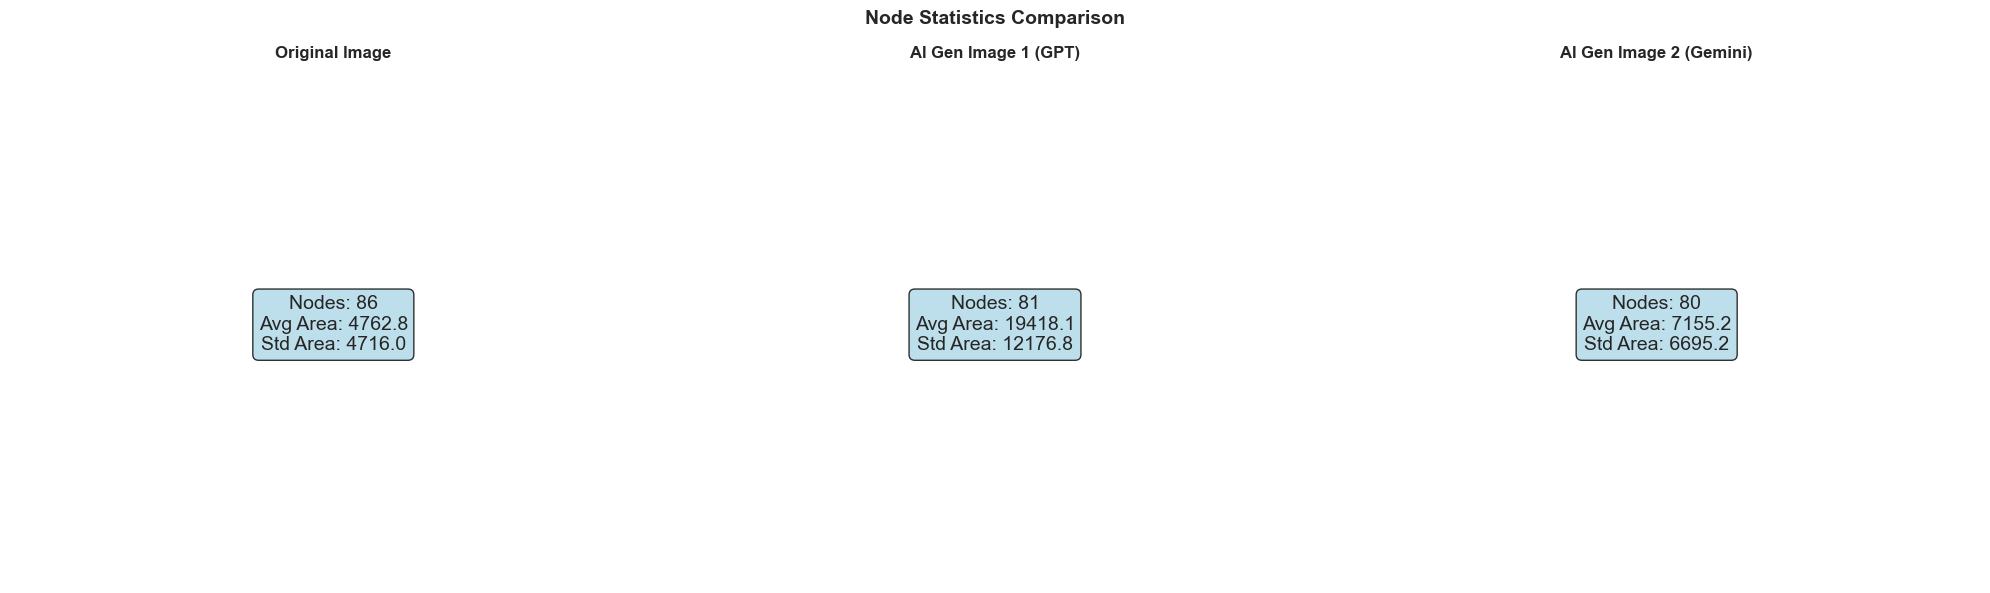

,Image,Node Count,Mean Area,Std Area
0,Original Image,86,4762.8,4716.0
1,AI Gen Image 1 (GPT),81,19418.1,12176.8
2,AI Gen Image 2 (Gemini),80,7155.2,6695.2


In [27]:
# Comparative Node Analysis - Side by Side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = list(datasets.keys())

for i, (title, data) in enumerate(datasets.items()):
    ax = axes[i]
    if 'nodes_df' in data:
        nodes_df = data['nodes_df']
        # Show node count and key stats
        stats_text = f"Nodes: {len(nodes_df)}\n"
        if 'area' in nodes_df.columns:
            stats_text += f"Avg Area: {nodes_df['area'].mean():.1f}\n"
            stats_text += f"Std Area: {nodes_df['area'].std():.1f}"
        ax.text(0.5, 0.5, stats_text, ha='center', va='center', fontsize=14, 
                transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Node Statistics Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
summary_data = []
for title, data in datasets.items():
    if 'nodes_df' in data:
        nodes_df = data['nodes_df']
        row = {'Image': title, 'Node Count': len(nodes_df)}
        if 'area' in nodes_df.columns:
            row['Mean Area'] = f"{nodes_df['area'].mean():.1f}"
            row['Std Area'] = f"{nodes_df['area'].std():.1f}"
        summary_data.append(row)

display(pd.DataFrame(summary_data))

**🔬 Executive Inference - Node Analysis:**  
AI-generated images show different superpixel segmentation patterns compared to the original, with variations in node count indicating differences in structural complexity and texture granularity. Higher node counts typically suggest finer detail preservation, while lower counts may indicate smoother, less textured regions.

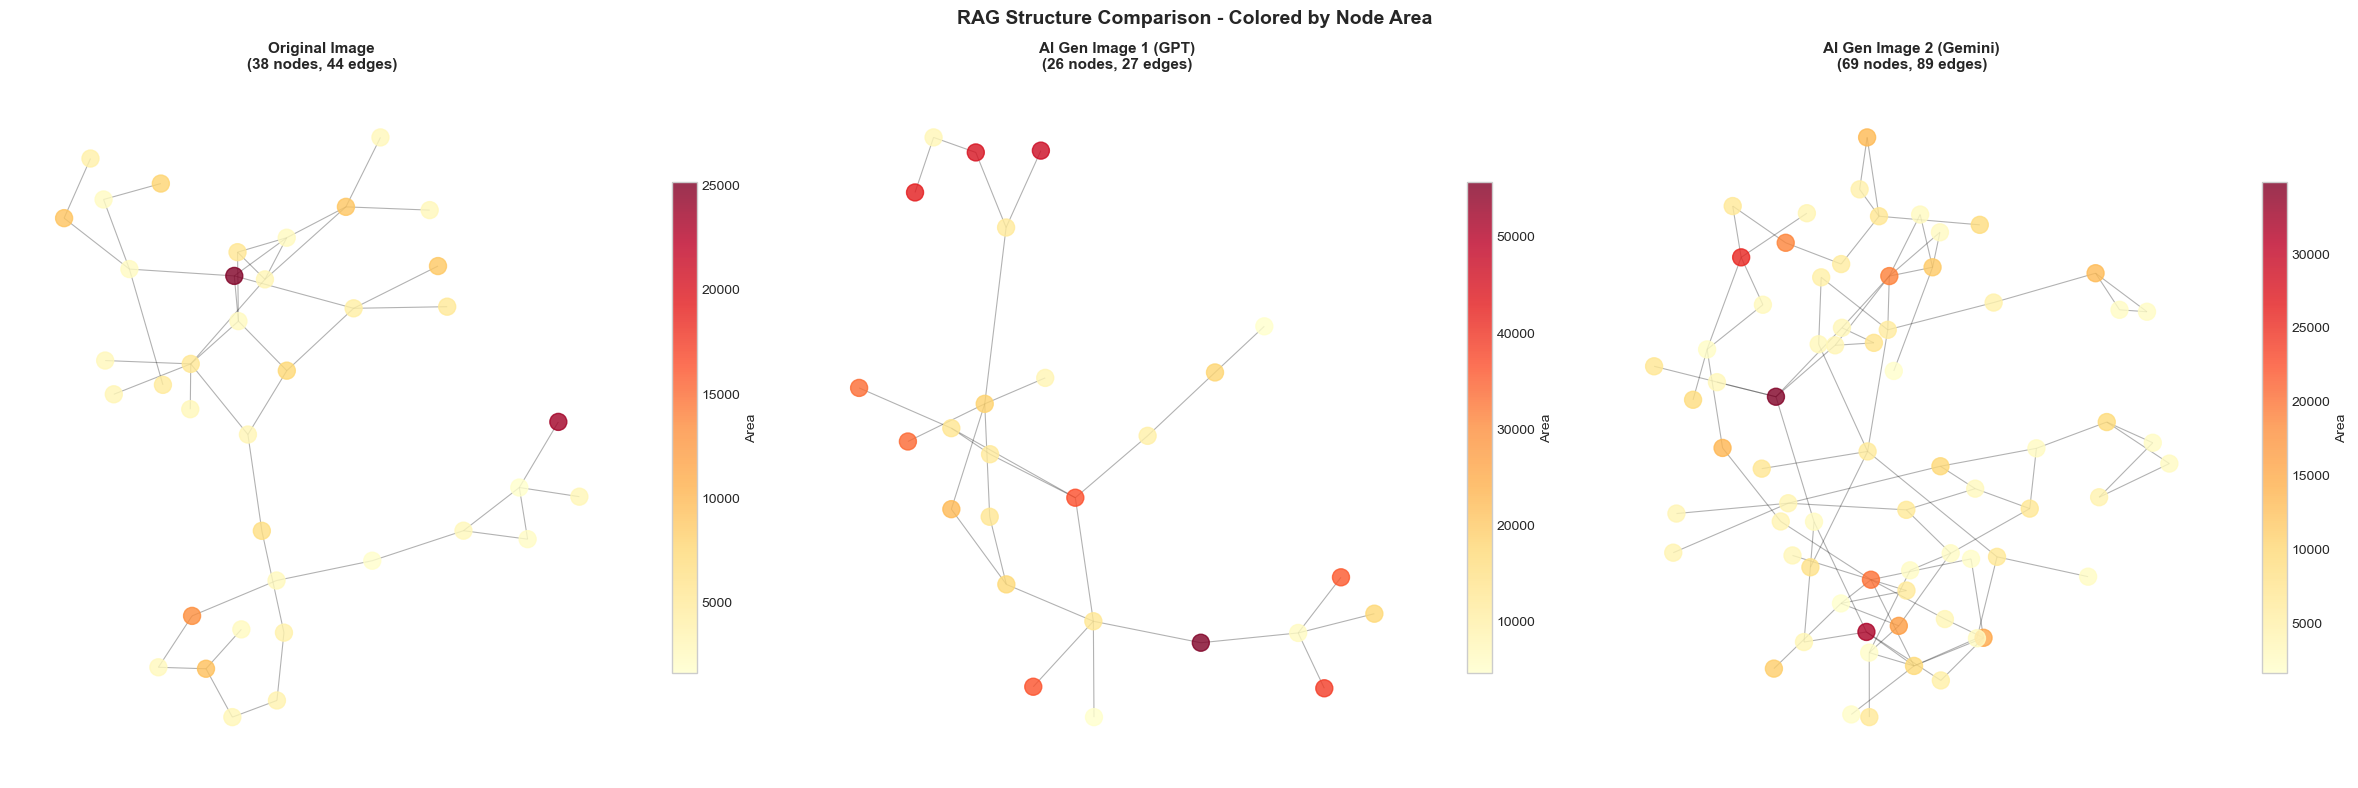

In [28]:
# Comparative Graph Structure - Side by Side
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for i, (title, data) in enumerate(datasets.items()):
    ax = axes[i]
    if 'G' in data:
        G = data['G']
        pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
        
        # Color by area if available
        if 'nodes_df' in data and 'area' in data['nodes_df'].columns:
            nodes_df = data['nodes_df']
            area_map = dict(zip(nodes_df['node'].astype(str), nodes_df['area']))
            node_colors = [area_map.get(str(n), 0) for n in G.nodes()]
            nodes_drawn = nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.YlOrRd,
                                                  node_size=150, alpha=0.8, ax=ax)
            plt.colorbar(nodes_drawn, ax=ax, label='Area', shrink=0.7)
        else:
            nx.draw_networkx_nodes(G, pos, node_color='steelblue', node_size=150, alpha=0.8, ax=ax)
        
        nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.8, ax=ax)
        ax.set_title(f"{title}\n({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)", 
                     fontsize=11, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Graph not available', ha='center', va='center')
    ax.axis('off')

plt.suptitle('RAG Structure Comparison - Colored by Node Area', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**🔬 Executive Inference - Graph Structure:**  
The topological differences between original and AI-generated graphs reveal how generative models create spatial relationships. Denser graphs with more edges suggest higher local connectivity, while sparser structures may indicate simplified texture representation or loss of fine-grained spatial detail.

## 3. Edge Analysis

Explore the edges connecting superpixels:

In [8]:
# Comparative Edge Analysis
edge_summary = []
for title, data in datasets.items():
    if 'edges_df' in data:
        edges_df = data['edges_df']
        row = {'Image': title, 'Edge Count': len(edges_df)}
        for col in ['weight', 'weight2', 'color_dist']:
            if col in edges_df.columns:
                row[f'Mean {col}'] = f"{edges_df[col].mean():.3f}"
                row[f'Std {col}'] = f"{edges_df[col].std():.3f}"
                break
        edge_summary.append(row)

print("🔗 Edge Statistics Comparison:")
display(pd.DataFrame(edge_summary))

🔗 Total edges: 218

📋 Edge data:


,source,target,weight,weight2,color_dist,boundary_contrast
0,0,1,0.000000,0.000000,0.000000,0.0
1,0,18,80.684182,0.316409,0.316409,0.0
2,1,2,3.624797,0.014215,0.014215,0.0
3,1,18,80.684182,0.316409,0.316409,0.0
4,1,21,13.694769,0.053705,0.053705,0.0
5,2,3,2.439923,0.009568,0.009568,0.0
6,2,21,10.078411,0.039523,0.039523,0.0
7,2,20,109.148464,0.428033,0.428033,0.0
8,3,4,0.390129,0.001530,0.001530,0.0
9,3,20,111.585279,0.437589,0.437589,0.0


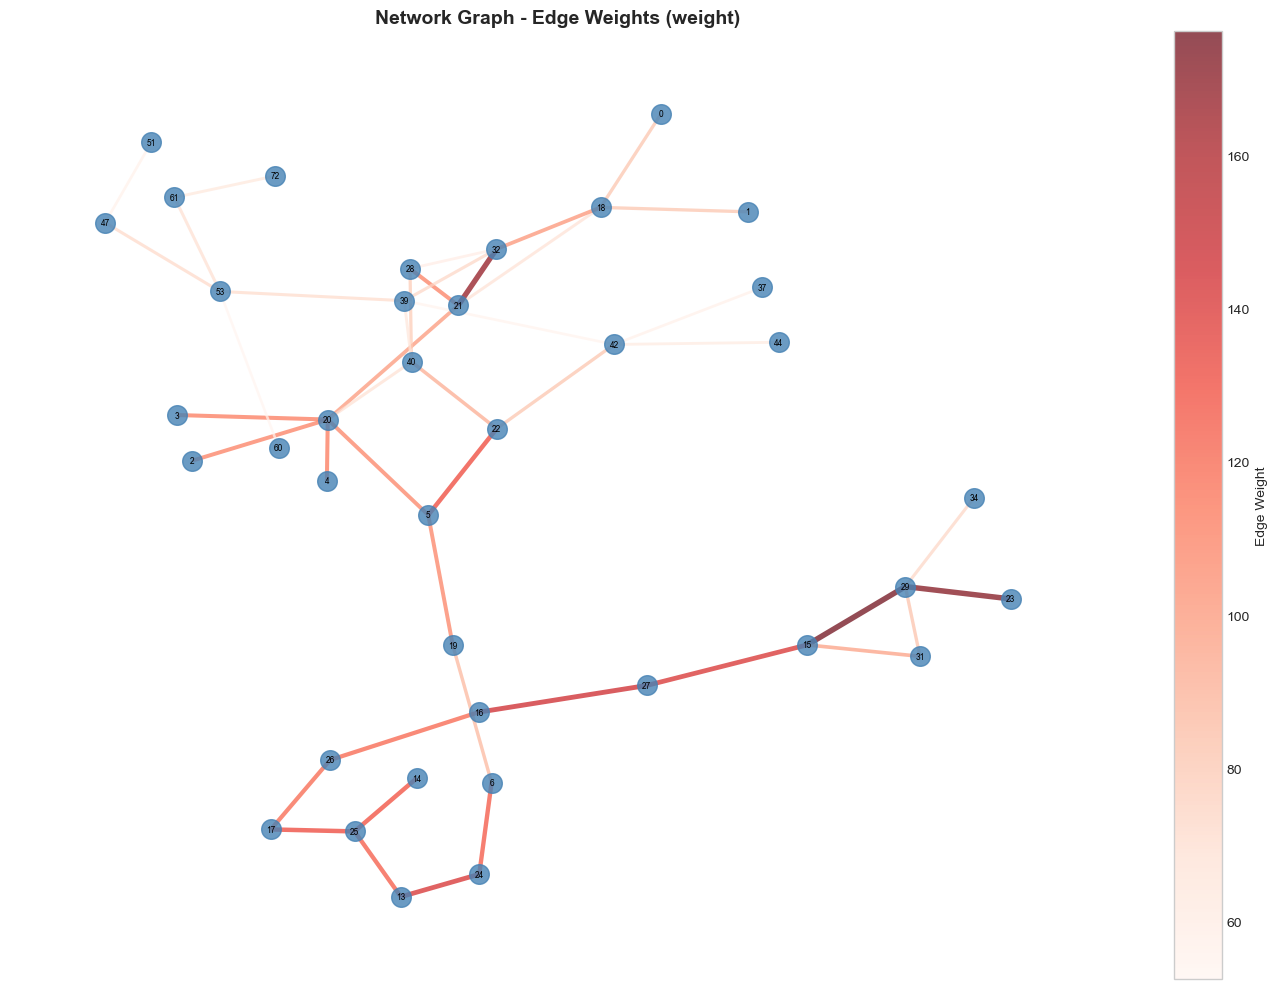

In [9]:
# Comparative Edge Weight Visualization
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for i, (title, data) in enumerate(datasets.items()):
    ax = axes[i]
    if 'G' in data:
        G = data['G']
        pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
        
        # Get edge weights
        weight_col = None
        for col in ['weight', 'weight2', 'color_dist']:
            if 'edges_df' in data and col in data['edges_df'].columns:
                weight_col = col
                break
        
        edge_weights = []
        for u, v in G.edges():
            w = G[u][v].get(weight_col, G[u][v].get('weight', 1)) if weight_col else 1
            try:
                edge_weights.append(float(w))
            except:
                edge_weights.append(1.0)
        
        if edge_weights and max(edge_weights) > 0:
            max_w = max(edge_weights)
            edge_widths = [1 + 2 * (w / max_w) for w in edge_weights]
        else:
            edge_widths = 1
        
        nx.draw_networkx_nodes(G, pos, node_color='steelblue', node_size=100, alpha=0.8, ax=ax)
        edges_drawn = nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_weights if edge_weights else 'gray',
                                              edge_cmap=plt.cm.Reds, alpha=0.7, ax=ax)
        if edges_drawn and edge_weights:
            plt.colorbar(edges_drawn, ax=ax, label='Edge Weight', shrink=0.7)
        
        ax.set_title(f"{title}", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Edge Weight Comparison Across Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**🔬 Executive Inference - Edge Weights:**  
Edge weight distributions reflect color similarity between adjacent regions. AI-generated images often show more uniform edge weights, suggesting smoother color transitions, while original images exhibit greater weight variance indicating natural texture heterogeneity and sharper boundaries.

## 4. Centrality Analysis

View the centrality measures for nodes:

In [32]:
# Comparative Centrality Analysis
centrality_summary = []
for title, data in datasets.items():
    if 'centrality_df' in data:
        cdf = data['centrality_df']
        row = {'Image': title}
        for measure in ['betweenness', 'closeness', 'eigenvector', 'degree']:
            if measure in cdf.columns:
                row[f'Mean {measure[:4].title()}'] = f"{cdf[measure].mean():.4f}"
        centrality_summary.append(row)

print("📊 Centrality Measures Comparison:")
display(pd.DataFrame(centrality_summary))

📊 Centrality Measures Comparison:


,Image,Mean Betw,Mean Clos,Mean Eige,Mean Degr
0,Original Image,0.1646,0.3749,0.0938,2.3158
1,AI Gen Image 1 (GPT),0.1483,0.6639,0.1343,2.0769
2,AI Gen Image 2 (Gemini),0.0911,0.4241,0.0388,2.5797


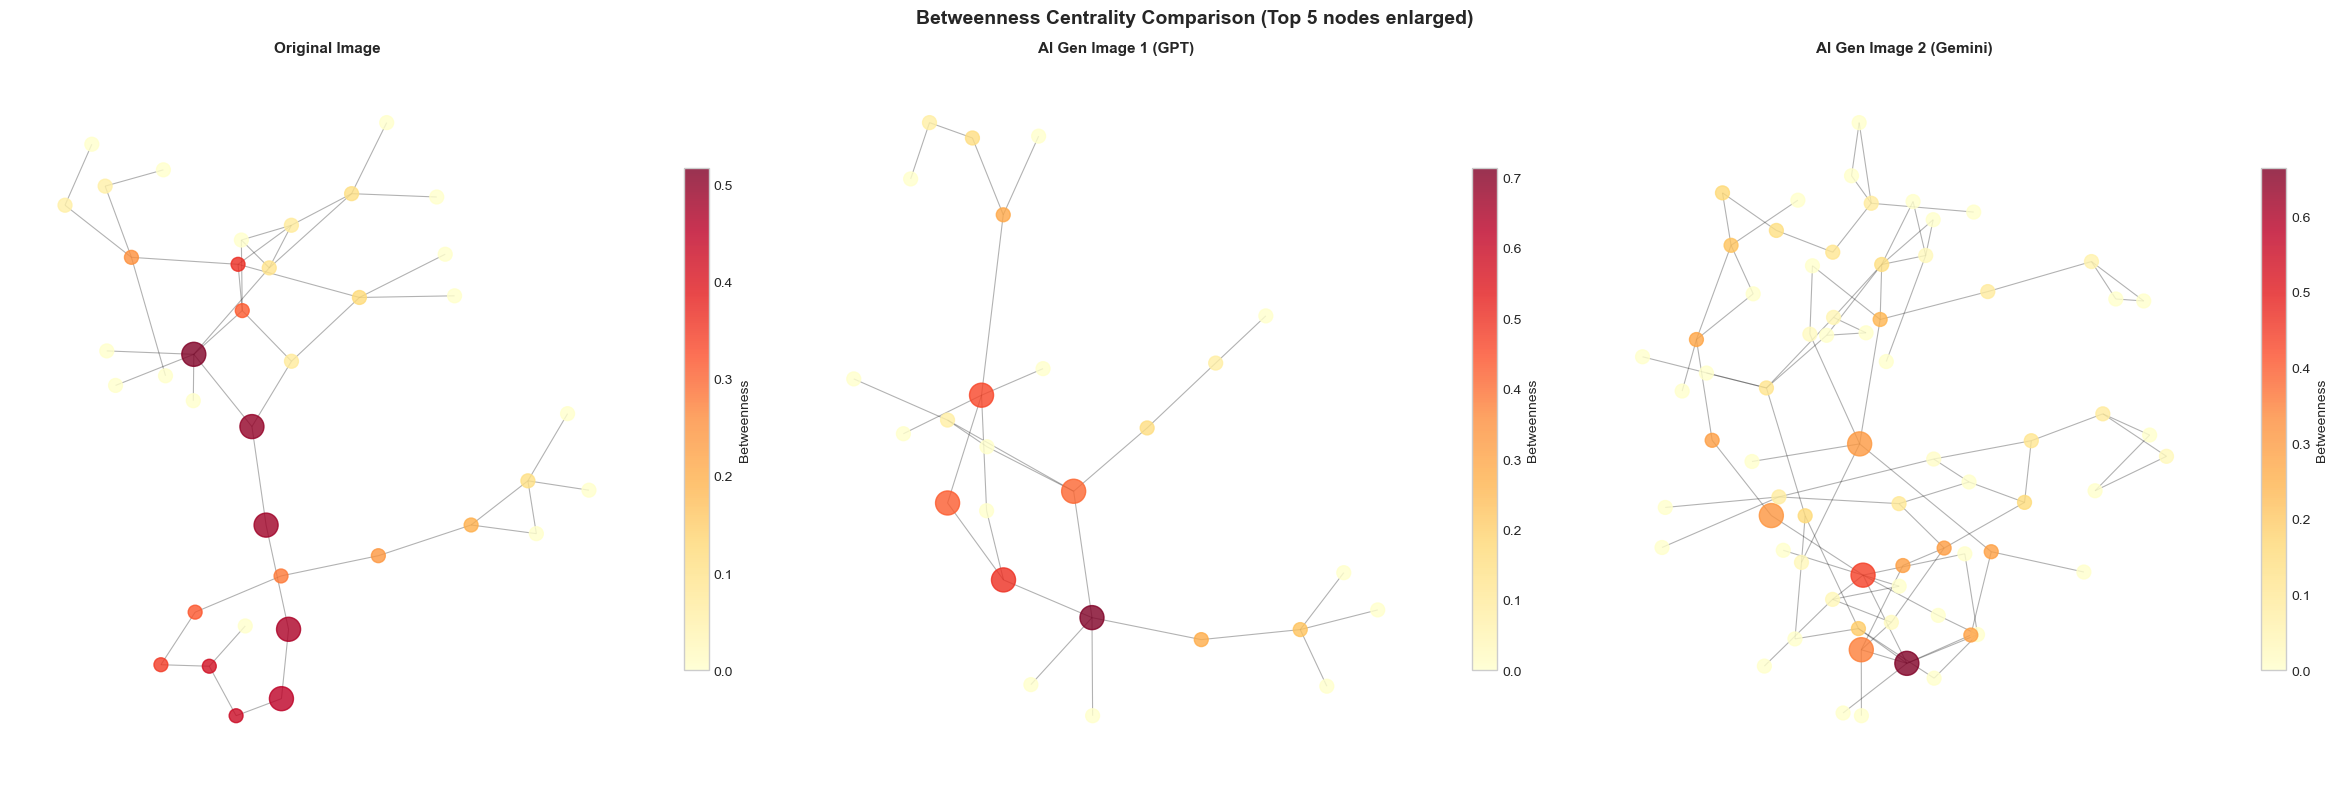

In [33]:
# Comparative Betweenness Centrality Visualization
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for i, (title, data) in enumerate(datasets.items()):
    ax = axes[i]
    if 'G' in data and 'centrality_df' in data:
        G = data['G']
        cdf = data['centrality_df']
        pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
        
        if 'betweenness' in cdf.columns:
            centrality_map = dict(zip(cdf['node'].astype(str), cdf['betweenness']))
            node_colors = [centrality_map.get(str(n), 0) for n in G.nodes()]
            top_5 = set(cdf.nlargest(5, 'betweenness')['node'].astype(str).tolist())
            node_sizes = [300 if str(n) in top_5 else 100 for n in G.nodes()]
            
            nodes_drawn = nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.YlOrRd,
                                                  node_size=node_sizes, alpha=0.8, ax=ax)
            nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.8, ax=ax)
            plt.colorbar(nodes_drawn, ax=ax, label='Betweenness', shrink=0.7)
        
        ax.set_title(f"{title}", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Betweenness Centrality Comparison (Top 5 nodes enlarged)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**🔬 Executive Inference - Centrality Analysis:**  
Betweenness centrality identifies critical "bridge" nodes connecting different image regions. Differences in centrality distributions between original and AI-generated images reveal how generative models create information flow pathways—higher centrality variance suggests more hierarchical structure, while uniform centrality indicates homogeneous connectivity patterns.

## 5. Community Detection

Analyze the detected communities:

In [34]:
# Comparative Community Analysis
community_summary = []
for title, data in datasets.items():
    if 'communities_df' in data:
        comm_df = data['communities_df']
        row = {'Image': title, 'Communities': len(comm_df)}
        if 'size' in comm_df.columns:
            row['Avg Size'] = f"{comm_df['size'].mean():.1f}"
            row['Max Size'] = comm_df['size'].max()
        community_summary.append(row)

print("🏘️ Community Statistics Comparison:")
display(pd.DataFrame(community_summary))

🏘️ Community Statistics Comparison:


,Image,Communities,Avg Size,Max Size
0,Original Image,7,5.4,7
1,AI Gen Image 1 (GPT),6,4.3,8
2,AI Gen Image 2 (Gemini),9,7.7,13


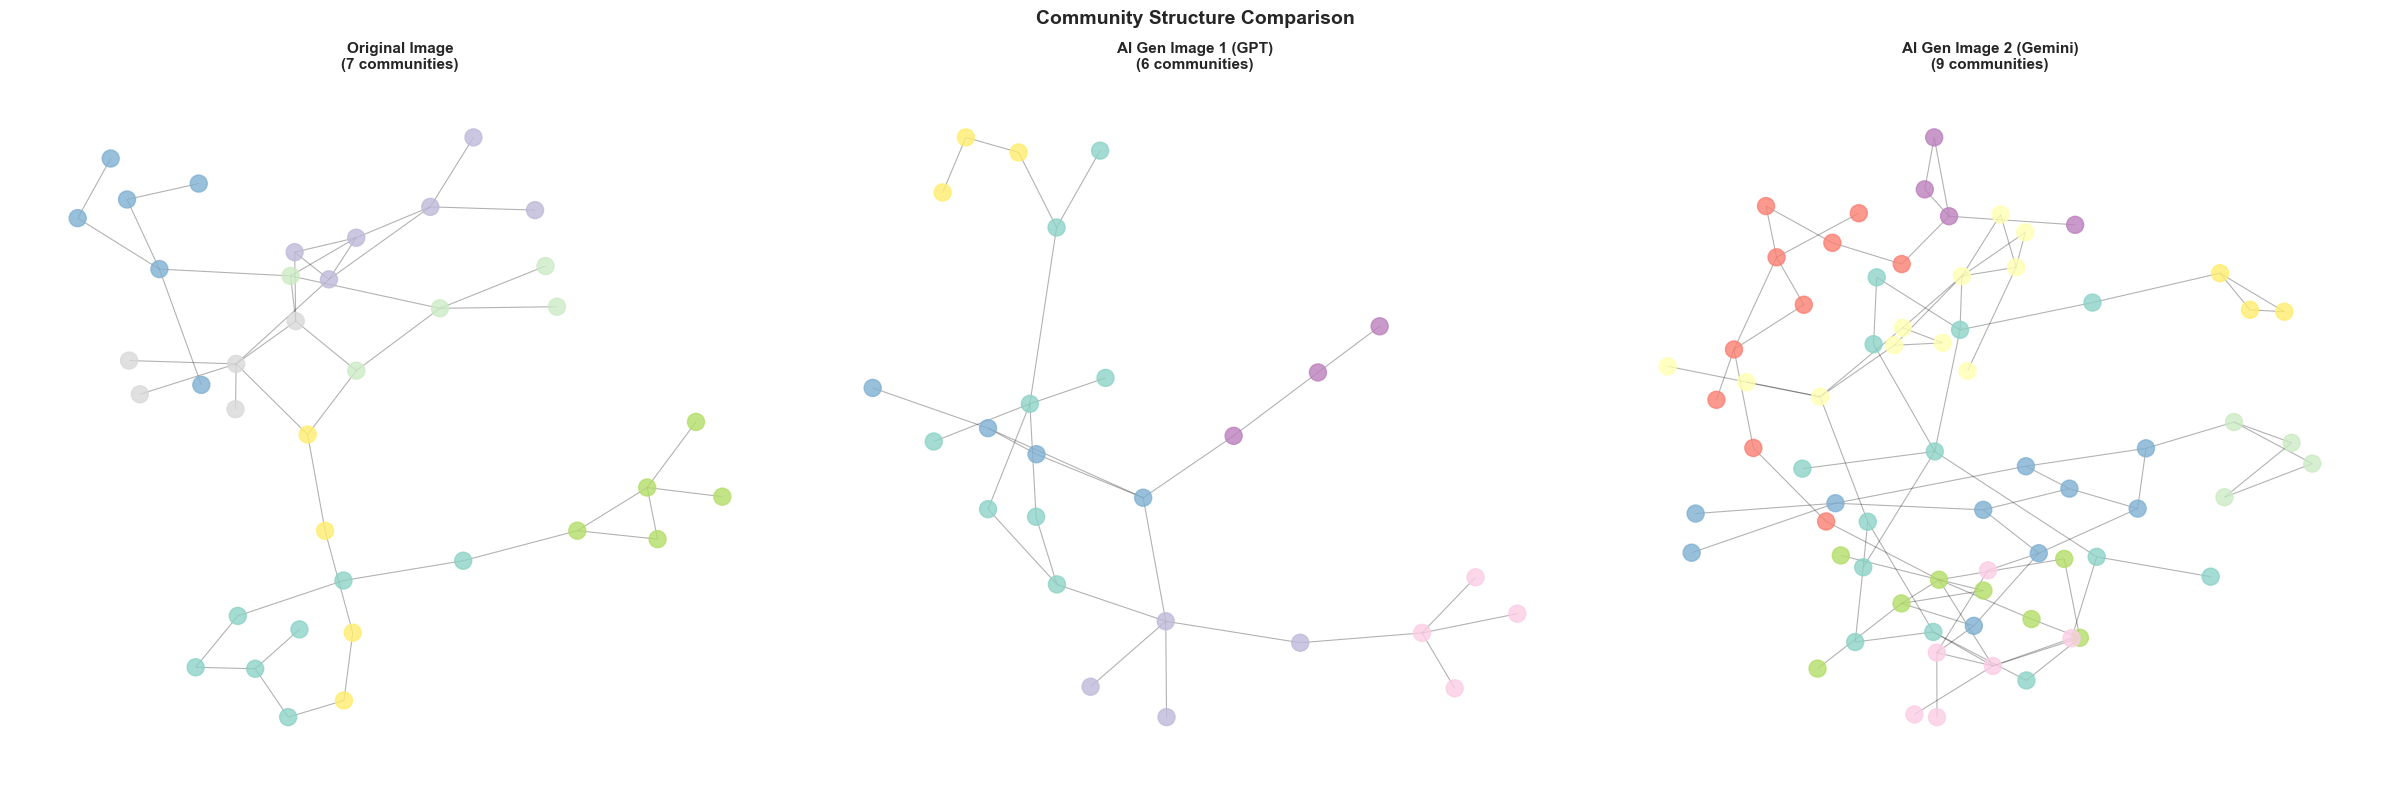

In [35]:
# Comparative Community Visualization
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for i, (title, data) in enumerate(datasets.items()):
    ax = axes[i]
    if 'G' in data and 'centrality_df' in data and 'community_id' in data['centrality_df'].columns:
        G = data['G']
        cdf = data['centrality_df']
        pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
        
        comm_map = dict(zip(cdf['node'].astype(str), cdf['community_id']))
        unique_communities = sorted(set(comm_map.values()))
        n_communities = len(unique_communities)
        
        cmap = plt.cm.Set3
        colors_list = [cmap(j / max(n_communities-1, 1)) for j in range(n_communities)]
        comm_to_color = {c: colors_list[j] for j, c in enumerate(unique_communities)}
        node_colors = [comm_to_color.get(comm_map.get(str(n), 0), 'lightgray') for n in G.nodes()]
        
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=150, alpha=0.8, ax=ax)
        nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.8, ax=ax)
        
        ax.set_title(f"{title}\n({n_communities} communities)", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Community Structure Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**🔬 Executive Inference - Community Detection:**  
Community structure reveals functional groupings of visually similar regions. AI-generated images may exhibit different community counts and sizes compared to originals—fewer, larger communities suggest simplified semantic structure, while more fragmented communities indicate preserved local texture complexity.

## 5.1 Spectral Clustering (Fiedler Vector)

Analyze graph partitioning using the Fiedler vector - the eigenvector corresponding to the second smallest eigenvalue of the graph Laplacian:

In [38]:
# Import spectral clustering module
import sys
sys.path.insert(0, str(Path('../superpixel_rag').resolve()))
from spectral_clustering import get_fiedler_stats, spectral_bipartition, spectral_clustering

# Comparative Fiedler Vector Statistics
print("📊 Fiedler Vector / Spectral Analysis Comparison")
print("=" * 80)

fiedler_summary = []
for title, data in datasets.items():
    if 'G' in data:
        G = data['G']
        stats = get_fiedler_stats(G)
        
        if stats.get('fiedler_value') is not None:
            row = {
                'Image': title,
                'λ₂ (Algebraic Conn.)': f"{stats['fiedler_value']:.4f}",
                'Partition Balance': f"{stats['partition_balance']:.2%}",
                'Cut Edges': stats['cut_edges'],
                'Cut Ratio': f"{stats['cut_ratio']:.2%}"
            }
            # Store fiedler data for visualization
            data['fiedler_stats'] = stats
        else:
            row = {'Image': title, 'λ₂ (Algebraic Conn.)': 'Error', 'Partition Balance': 'N/A'}
        
        fiedler_summary.append(row)

display(pd.DataFrame(fiedler_summary))

print("\n💡 Interpretation:")
print("• λ₂ (Algebraic Connectivity): Higher = more robust connectivity")
print("• Partition Balance: Closer to 100% = more even bipartition")
print("• Cut Ratio: Lower = cleaner spectral separation")

📊 Fiedler Vector / Spectral Analysis Comparison


,Image,λ₂ (Algebraic Conn.),Partition Balance,Cut Edges,Cut Ratio
0,Original Image,1.8277,58.33%,1,2.27%
1,AI Gen Image 1 (GPT),4.1697,73.33%,1,3.70%
2,AI Gen Image 2 (Gemini),2.1844,38.00%,4,4.49%



💡 Interpretation:
• λ₂ (Algebraic Connectivity): Higher = more robust connectivity
• Partition Balance: Closer to 100% = more even bipartition
• Cut Ratio: Lower = cleaner spectral separation


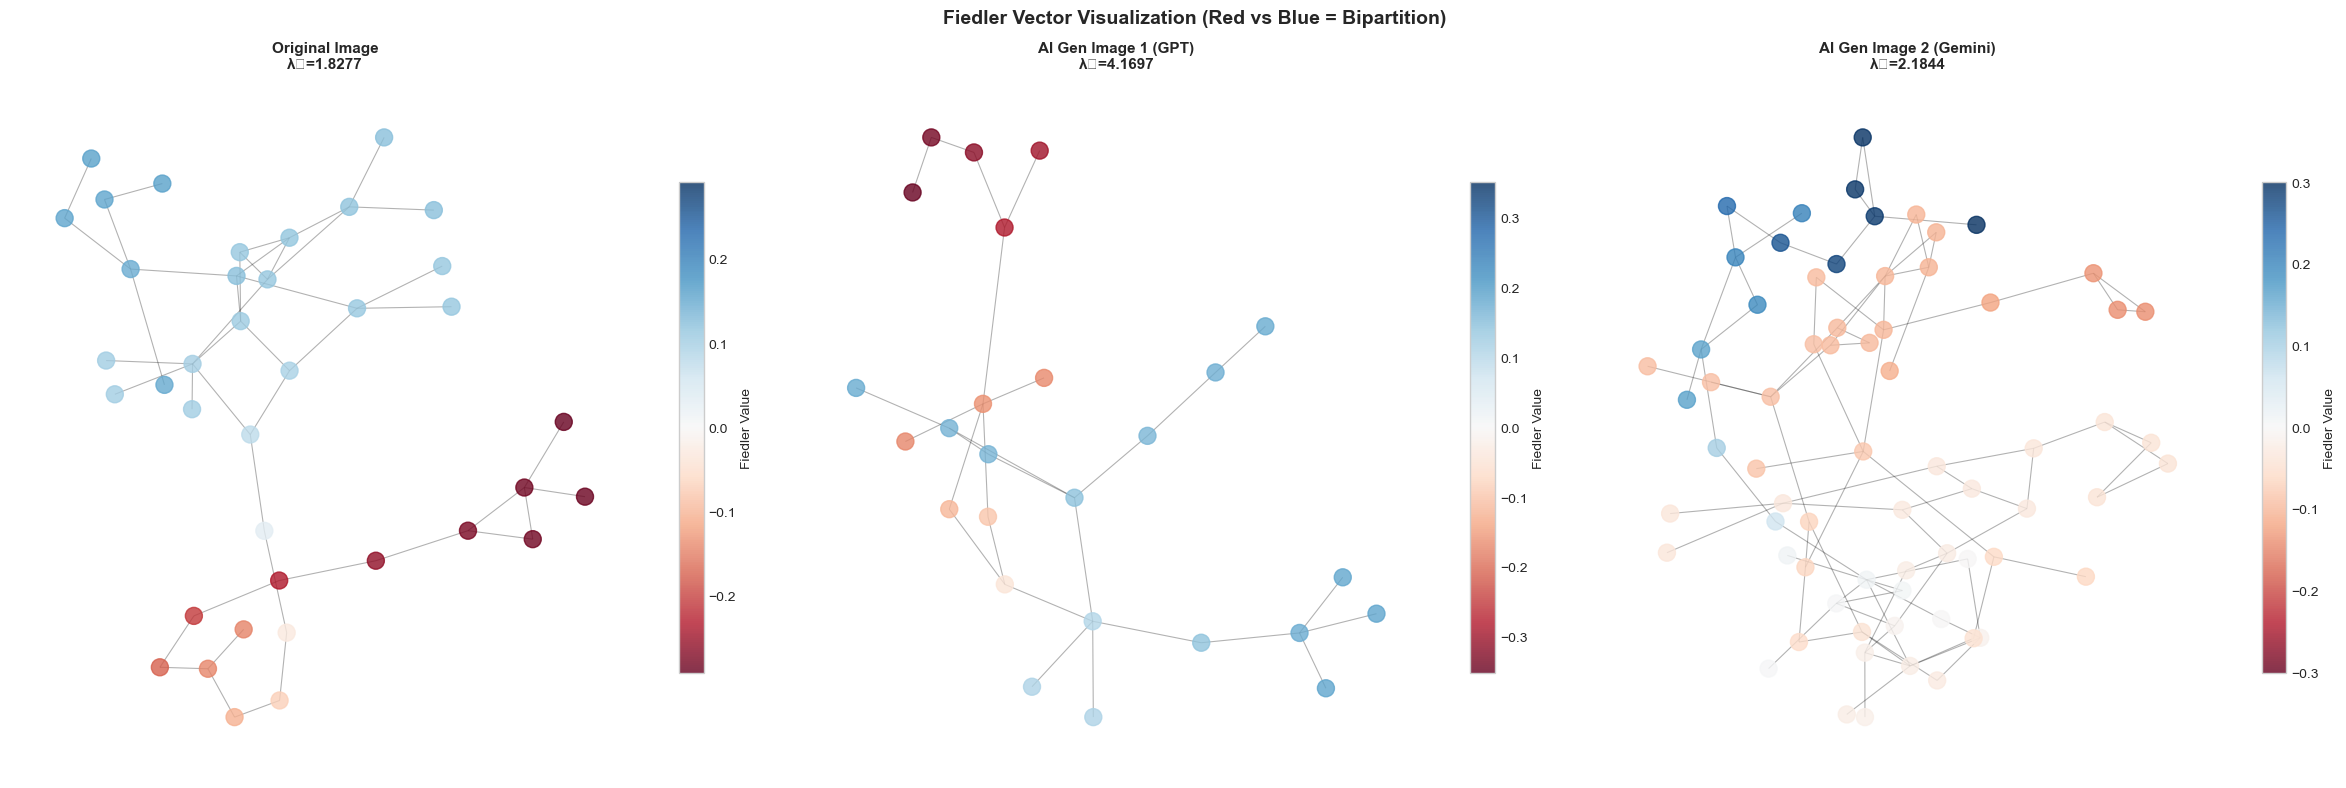

In [39]:
# Comparative Fiedler Vector Bipartition Visualization
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for i, (title, data) in enumerate(datasets.items()):
    ax = axes[i]
    if 'G' in data and 'fiedler_stats' in data:
        G = data['G']
        stats = data['fiedler_stats']
        pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
        
        # Get Fiedler vector values for coloring
        nodes = stats['nodes']
        fiedler_vec = stats['fiedler_vector']
        
        # Create node color map based on Fiedler values
        node_to_fiedler = {nodes[j]: fiedler_vec[j] for j in range(len(nodes))}
        node_colors = [node_to_fiedler.get(str(n), 0) for n in G.nodes()]
        
        # Draw graph with Fiedler coloring (diverging colormap)
        nodes_drawn = nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                                              cmap=plt.cm.RdBu, node_size=150, 
                                              alpha=0.8, ax=ax, vmin=-max(abs(min(fiedler_vec)), abs(max(fiedler_vec))),
                                              vmax=max(abs(min(fiedler_vec)), abs(max(fiedler_vec))))
        nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.8, ax=ax)
        plt.colorbar(nodes_drawn, ax=ax, label='Fiedler Value', shrink=0.7)
        
        ax.set_title(f"{title}\nλ₂={stats['fiedler_value']:.4f}", fontsize=11, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Data not available', ha='center', va='center')
    ax.axis('off')

plt.suptitle('Fiedler Vector Visualization (Red vs Blue = Bipartition)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

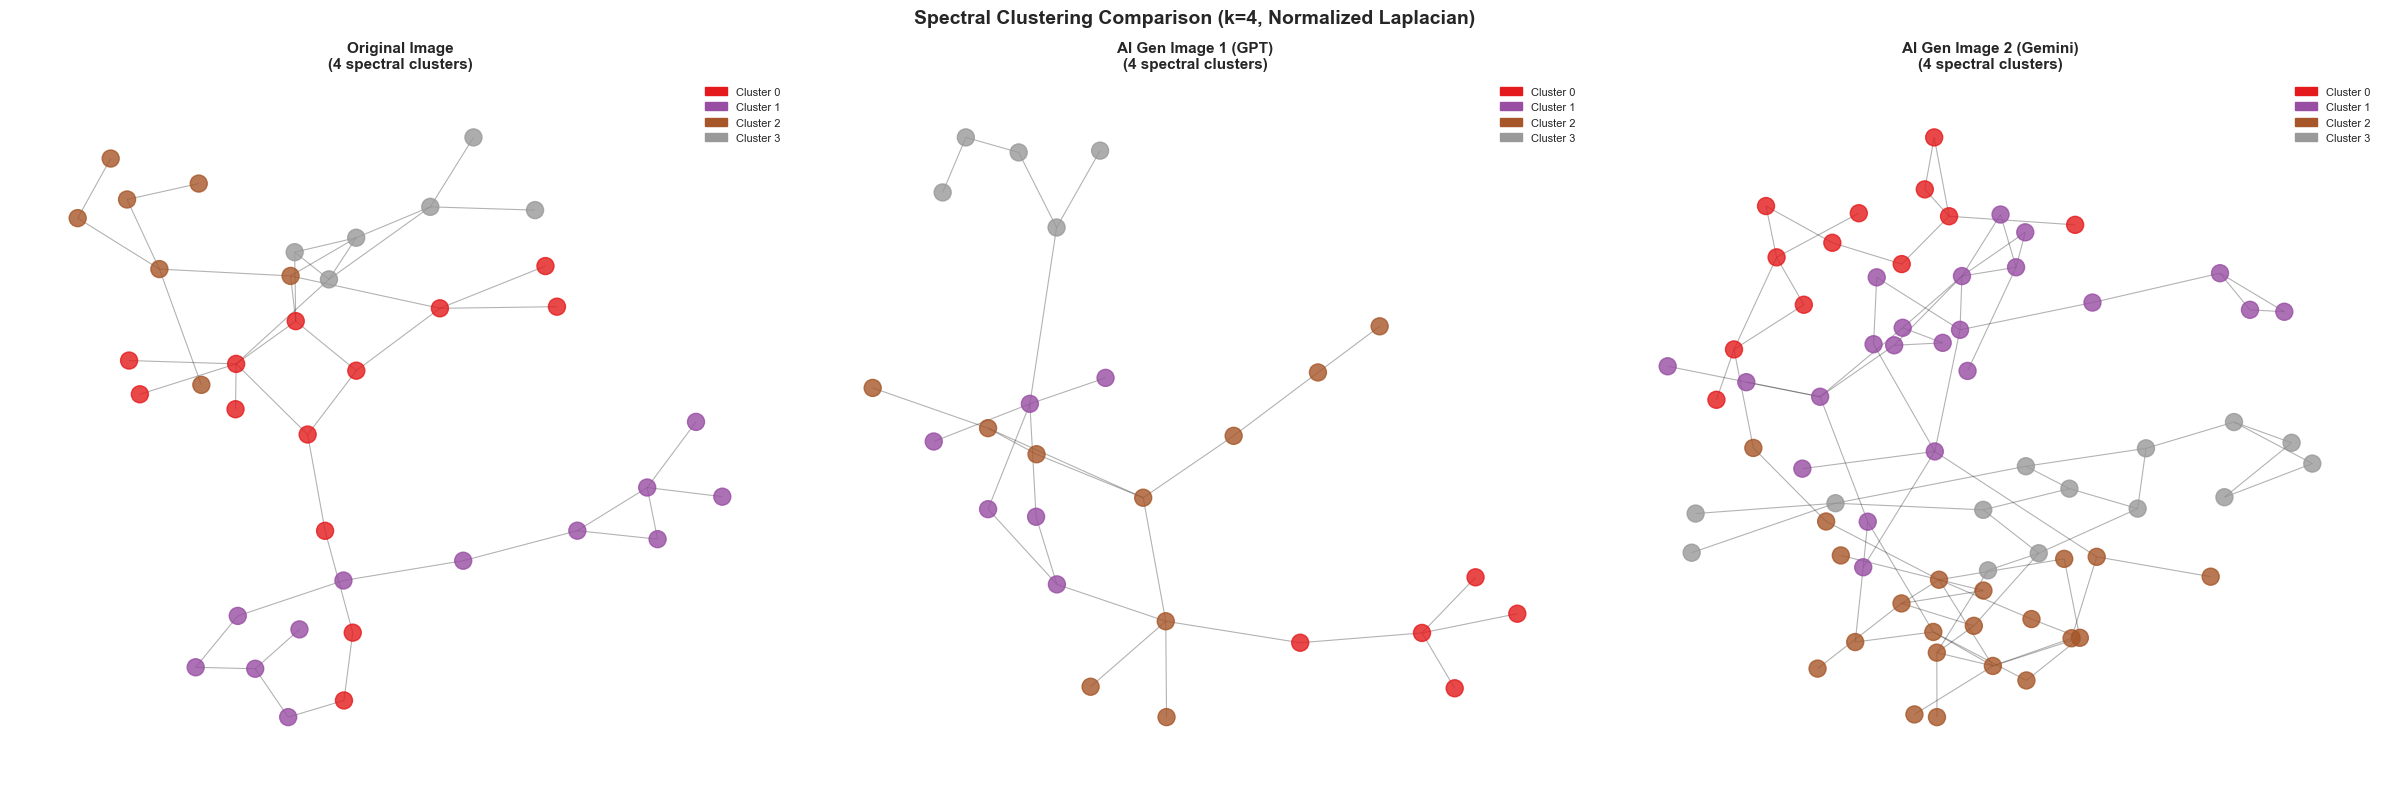

In [40]:
# Comparative Spectral Clustering (k=4) Visualization
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for i, (title, data) in enumerate(datasets.items()):
    ax = axes[i]
    if 'G' in data:
        G = data['G']
        pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
        
        # Perform spectral clustering with k=4
        try:
            clusters = spectral_clustering(G, n_clusters=4, normalized=True)
            n_clusters = len(set(clusters.values()))
            
            # Color by cluster
            cmap = plt.cm.Set1
            node_colors = [cmap(clusters.get(str(n), 0) / max(n_clusters-1, 1)) for n in G.nodes()]
            
            nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=150, alpha=0.8, ax=ax)
            nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.8, ax=ax)
            
            # Add legend
            legend_patches = [mpatches.Patch(color=cmap(j/max(n_clusters-1,1)), label=f'Cluster {j}') 
                             for j in range(n_clusters)]
            ax.legend(handles=legend_patches, loc='upper right', fontsize=8)
            
            ax.set_title(f"{title}\n({n_clusters} spectral clusters)", fontsize=11, fontweight='bold')
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)[:30]}', ha='center', va='center')
    ax.axis('off')

plt.suptitle('Spectral Clustering Comparison (k=4, Normalized Laplacian)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**🔬 Executive Inference - Spectral Clustering (Fiedler Vector):**  
The algebraic connectivity (λ₂) measures graph robustness—higher values indicate tighter structural cohesion. AI-generated images showing different λ₂ values reveal how generative models alter the spectral properties of spatial relationships, with bipartition balance indicating whether images maintain symmetric regional organization or exhibit asymmetric clustering patterns.

## 6. Graph Visualization

Load and visualize the Region Adjacency Graph:

In [14]:
# Comprehensive Graph Statistics Comparison
graph_stats = []
for title, data in datasets.items():
    if 'G' in data:
        G = data['G']
        degrees = [d for n, d in G.degree()]
        row = {
            'Image': title,
            'Nodes': G.number_of_nodes(),
            'Edges': G.number_of_edges(),
            'Density': f"{nx.density(G):.4f}",
            'Connected': '✓' if nx.is_connected(G) else '✗',
            'Avg Degree': f"{np.mean(degrees):.2f}",
            'Max Degree': max(degrees)
        }
        graph_stats.append(row)

print("📈 Graph Statistics Comparison:")
display(pd.DataFrame(graph_stats))

📈 Graph Statistics:
   Nodes: 38
   Edges: 44
   Connected: True
   Density: 0.0626
   Avg Degree: 2.32
   Max Degree: 6
   Min Degree: 1


**🔬 Executive Inference - Graph Properties:**  
Graph density and connectivity metrics quantify overall structural complexity. Higher density in AI-generated images may indicate over-smoothed regions with excessive neighbor connections, while lower density could suggest loss of fine-grained spatial relationships present in the original histopathology image.

## 7. Anomaly Detection

View detected anomalies in the graph:

In [36]:
# Comparative Anomaly Analysis
anomaly_summary = []
for title, data in datasets.items():
    if 'anomalies_df' in data:
        adf = data['anomalies_df']
        row = {'Image': title, 'Anomaly Count': len(adf)}
        if 'G' in data:
            row['% of Nodes'] = f"{100 * len(adf) / data['G'].number_of_nodes():.1f}%"
        anomaly_summary.append(row)

print("⚠️ Anomaly Detection Comparison:")
display(pd.DataFrame(anomaly_summary))

⚠️ Anomaly Detection Comparison:


,Image,Anomaly Count,% of Nodes
0,Original Image,38,100.0%
1,AI Gen Image 1 (GPT),26,100.0%
2,AI Gen Image 2 (Gemini),69,100.0%


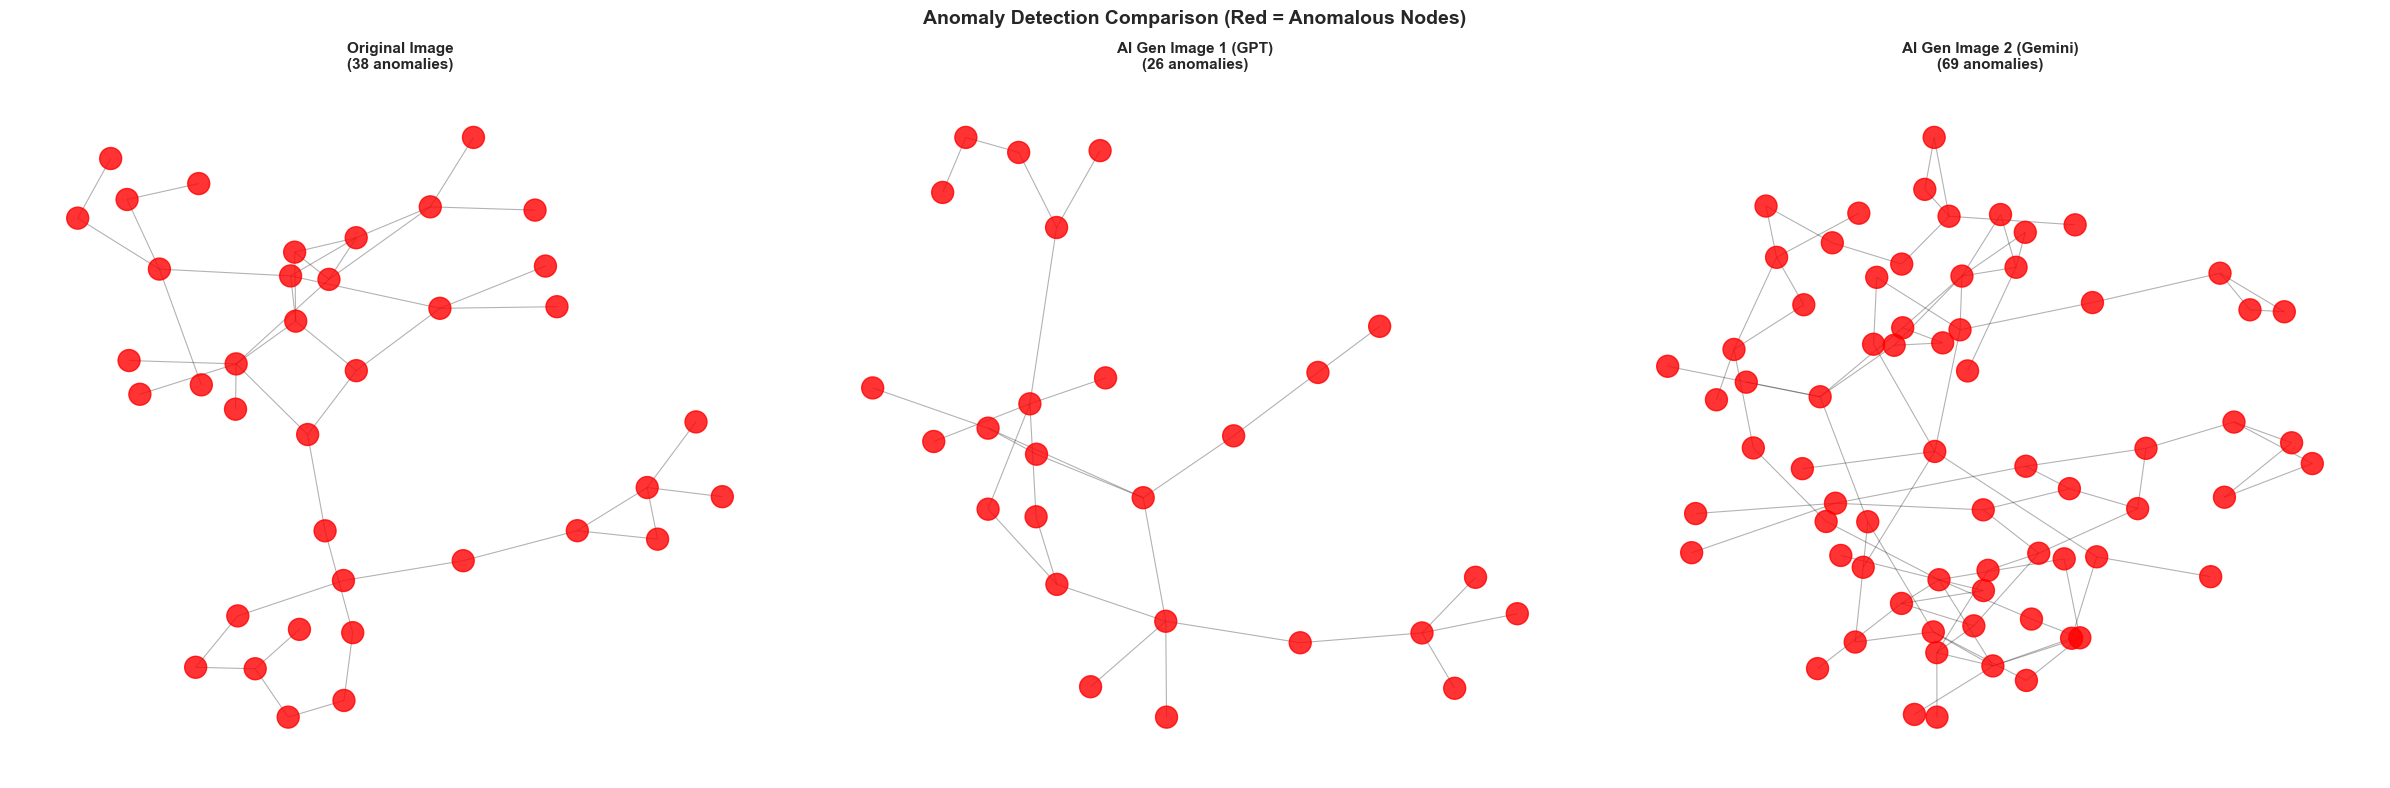

In [37]:
# Comparative Anomaly Visualization
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for i, (title, data) in enumerate(datasets.items()):
    ax = axes[i]
    if 'G' in data:
        G = data['G']
        pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
        
        anomaly_nodes = set()
        if 'anomalies_df' in data and len(data['anomalies_df']) > 0:
            adf = data['anomalies_df']
            anomaly_col = 'node' if 'node' in adf.columns else adf.columns[0]
            anomaly_nodes = set(adf[anomaly_col].astype(str).tolist())
        
        node_colors = ['red' if str(n) in anomaly_nodes else 'steelblue' for n in G.nodes()]
        node_sizes = [250 if str(n) in anomaly_nodes else 100 for n in G.nodes()]
        
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8, ax=ax)
        nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.8, ax=ax)
        
        ax.set_title(f"{title}\n({len(anomaly_nodes)} anomalies)", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Anomaly Detection Comparison (Red = Anomalous Nodes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**🔬 Executive Inference - Anomaly Detection:**  
Anomalous nodes represent regions with atypical structural properties (unusual connectivity, size, or centrality). Comparing anomaly rates between original and AI-generated images reveals how generative models handle outlier regions—lower anomaly counts in AI images may indicate over-regularization of natural variation.

## 8. AI Analysis Summary

View the AI-generated insights:

In [29]:
# Comparative AI Analysis Summary
print("🤖 AI Analysis Summary Comparison")
print("=" * 80)

for title, data in datasets.items():
    output_dir = data['output_dir']
    digest_path = output_dir / 'phase4_digest.json'
    summary_path = output_dir / 'phase4_exec_summary.txt'
    
    print(f"\n📌 {title}")
    print("-" * 40)
    
    # Load digest
    if digest_path.exists():
        with open(digest_path) as f:
            digest = json.load(f)
        print(f"  Digest Keys: {list(digest.keys())[:5]}...")
        if 'summary' in digest:
            summary_text = str(digest['summary'])[:200]
            print(f"  Summary: {summary_text}...")
    else:
        print("  ⚠️ Phase 4 digest not found")
    
    # Load executive summary
    if summary_path.exists():
        with open(summary_path) as f:
            exec_summary = f.read()[:300]
        print(f"  Executive Summary Preview:\n    {exec_summary[:200]}...")
    else:
        print("  ⚠️ Executive summary not found")

print("\n" + "=" * 80)

🤖 AI Analysis Summary Comparison

📌 Original Image
----------------------------------------
  Digest Keys: ['stats', 'top_nodes', 'community_summary', 'weight_stats', 'sample_subgraph']...
  Executive Summary Preview:
    The image analysis graph contains 38 superpixel nodes and 44 edges. The structure exhibits 1 connected components with an average degree of 2.32. Community detection identified 7 distinct regions, sug...

📌 AI Gen Image 1 (GPT)
----------------------------------------
  Digest Keys: ['stats', 'top_nodes', 'community_summary', 'weight_stats', 'sample_subgraph']...
  Executive Summary Preview:
    The image analysis graph contains 26 superpixel nodes and 27 edges. The structure exhibits 1 connected components with an average degree of 2.08. Community detection identified 6 distinct regions, sug...

📌 AI Gen Image 2 (Gemini)
----------------------------------------
  Digest Keys: ['stats', 'top_nodes', 'community_summary', 'weight_stats', 'sample_subgraph']...
  Executiv

**🔬 Executive Inference - AI Analysis:**  
Phase 4 AI-generated digests provide semantic interpretation of graph structure. Comparing these summaries across original and AI-generated images reveals how automated analysis systems characterize structural differences in tissue representation.

## 9. RAG Export Data

View the detailed RAG export files:

In [30]:
# Comparative RAG Export Data Analysis
print("📦 RAG Export Data Comparison")
print("=" * 80)

rag_summary = []
for title, data in datasets.items():
    output_dir = data['output_dir']
    rag_nodes_path = output_dir / 'rag_nodes.csv'
    rag_edges_path = output_dir / 'rag_edges.csv'
    
    row = {'Image': title}
    
    if rag_nodes_path.exists():
        rag_nodes_df = pd.read_csv(rag_nodes_path)
        row['RAG Nodes'] = len(rag_nodes_df)
        row['Node Cols'] = len(rag_nodes_df.columns)
    else:
        row['RAG Nodes'] = 'N/A'
    
    if rag_edges_path.exists():
        rag_edges_df = pd.read_csv(rag_edges_path)
        row['RAG Edges'] = len(rag_edges_df)
        row['Edge Cols'] = len(rag_edges_df.columns)
    else:
        row['RAG Edges'] = 'N/A'
    
    rag_summary.append(row)

display(pd.DataFrame(rag_summary))

# Show column names for each dataset
print("\n📋 RAG Node Features by Image:")
for title, data in datasets.items():
    output_dir = data['output_dir']
    rag_nodes_path = output_dir / 'rag_nodes.csv'
    if rag_nodes_path.exists():
        rag_nodes_df = pd.read_csv(rag_nodes_path)
        print(f"\n{title}: {list(rag_nodes_df.columns)[:8]}...")

📦 RAG Export Data Comparison


,Image,RAG Nodes,Node Cols,RAG Edges,Edge Cols
0,Original Image,38,5,44,7
1,AI Gen Image 1 (GPT),26,5,27,7
2,AI Gen Image 2 (Gemini),69,5,89,7



📋 RAG Node Features by Image:

Original Image: ['node', 'labels', 'pixel count', 'total color', 'mean color']...

AI Gen Image 1 (GPT): ['node', 'labels', 'pixel count', 'total color', 'mean color']...

AI Gen Image 2 (Gemini): ['node', 'labels', 'pixel count', 'total color', 'mean color']...


**🔬 Executive Inference - RAG Export Data:**  
RAG export files contain enriched node and edge features optimized for downstream ML/AI applications. Consistent feature counts across datasets ensure compatibility for comparative machine learning models, while variations in value distributions reflect structural differences between original and generated images.

## 10. Summary Statistics

Overall summary of the analysis:

In [31]:
# Final Comparative Summary
print("=" * 80)
print("📊 COMPREHENSIVE COMPARATIVE ANALYSIS SUMMARY")
print("=" * 80)

summary_table = []
for title, data in datasets.items():
    row = {'Image': title}
    
    if 'G' in data:
        G = data['G']
        row['Nodes'] = G.number_of_nodes()
        row['Edges'] = G.number_of_edges()
        row['Density'] = f"{nx.density(G):.4f}"
        degrees = [d for n, d in G.degree()]
        row['Avg Degree'] = f"{np.mean(degrees):.2f}"
    
    if 'communities_df' in data:
        row['Communities'] = len(data['communities_df'])
    
    if 'anomalies_df' in data:
        row['Anomalies'] = len(data['anomalies_df'])
    
    summary_table.append(row)

display(pd.DataFrame(summary_table))

print("\n" + "=" * 80)
print("🔬 KEY COMPARATIVE FINDINGS")
print("=" * 80)
print("""
1. STRUCTURAL COMPLEXITY: Compare node/edge counts to assess detail preservation
2. CONNECTIVITY PATTERNS: Density and degree metrics reveal spatial relationship fidelity  
3. COMMUNITY STRUCTURE: Number and size of communities indicate semantic grouping similarity
4. ANOMALY RATES: Differences highlight how AI models handle outlier regions
""")
print("=" * 80)

📊 COMPREHENSIVE COMPARATIVE ANALYSIS SUMMARY


,Image,Nodes,Edges,Density,Avg Degree,Communities,Anomalies
0,Original Image,38,44,0.0626,2.32,7,38
1,AI Gen Image 1 (GPT),26,27,0.0831,2.08,6,26
2,AI Gen Image 2 (Gemini),69,89,0.0379,2.58,9,69



🔬 KEY COMPARATIVE FINDINGS

1. STRUCTURAL COMPLEXITY: Compare node/edge counts to assess detail preservation
2. CONNECTIVITY PATTERNS: Density and degree metrics reveal spatial relationship fidelity  
3. COMMUNITY STRUCTURE: Number and size of communities indicate semantic grouping similarity
4. ANOMALY RATES: Differences highlight how AI models handle outlier regions



**🔬 Executive Inference - Overall Comparison:**  
This comparative analysis reveals fundamental differences in how AI image generators represent spatial structure compared to original histopathology images. The graph-based approach provides quantitative metrics for evaluating generative model fidelity beyond pixel-level comparisons, enabling objective assessment of structural preservation in medical image synthesis.